# Régression logistique : entropie croisée et géométrie

CSI 4506 - automne 2026

Marcel Turcotte  
Version : 21 septembre 2026 09h35

# Préambule

## Message du jour

<https://youtu.be/cLFkoeWe1dQ>

Bazett, T. (30 août 2026). [*The Learning Crisis in
Academia*](https://youtu.be/cLFkoeWe1dQ) \[Vidéo\]. YouTube.

Trefor Bazett est professeur agrégé d’enseignement en mathématiques et
en statistique à l’[Université de
Victoria](https://www.uvic.ca/science/math-statistics/people/home/faculty/bazett_trefor.php).
Il a obtenu son doctorat en mathématiques à l’Université de Toronto. Ses
intérêts universitaires comprennent l’enseignement des mathématiques et
la topologie algébrique. En 2024, il a reçu le prix d’éducation du PIMS
pour sa contribution à l’enseignement des sciences mathématiques. Le
PIMS a notamment souligné son importante collection de vidéos de
mathématiques.

Les points suivants résument la vidéo et adaptent ses recommandations à
des exemples tirés de ce cours.

1.  **Apprentissage actif.** Tentez de résoudre un petit exemple avant
    de consulter l’IA. Après un premier effort, demandez une aide
    ciblée.
2.  **L’IA comme tuteur.** Présentez votre raisonnement ou votre code et
    demandez un indice conceptuel ou une question diagnostique.
3.  **Effort productif.** Effectuez vous-même les étapes importantes du
    raisonnement, comme l’application de la règle de dérivation en
    chaîne dans une dérivation de la rétropropagation. Utilisez ensuite
    l’IA pour vérifier votre travail.
4.  **Pratique de récupération.** Demandez à l’IA de produire des
    questions, répondez-y de mémoire, puis examinez la rétroaction.
5.  **Évaluation critique.** Vérifiez l’exactitude de la réponse et
    déterminez si elle emploie des méthodes appropriées au cours.

## Objectifs d’apprentissage

À la fin de cette présentation, vous devriez être en mesure de :

- **Dériver** l’entropie croisée binaire à partir de la vraisemblance de
  Bernoulli.
- **Expliquer** pourquoi l’entropie croisée binaire est préférée à l’EQM
  pour la régression logistique.
- **Interpréter** géométriquement la frontière de décision de la
  régression logistique et son vecteur normal.
- **Distinguer** le score linéaire, la probabilité correspondante et la
  distance signée.
- **Relier** le modèle mathématique à une mise en œuvre de la descente
  de gradient par lot.

# Rappel : régression logistique

## Problème

- **Cas général :** $P(y = k \mid x, \theta)$, où $k$ est une étiquette
  de classe.
- **Cas binaire :** $y \in \{0,1\}$
  - **Prédire** $P(y = 1 \mid x, \theta)$

Pour une nouvelle instance $x_{\textrm{new}}$, déterminer la probabilité
qu’elle appartienne à la classe $k$, notée
$P(y = k \mid x_{\textrm{new}}, \theta)$.

## Régression logistique

Le modèle de **régression logistique** est défini ainsi :

$$
  \hat{p}_i = h_\theta(x_i) = \sigma(\theta^\top x_i) = \frac{1}{1+e^{-\theta^\top x_i}}
  $$

- Les **prédictions** sont obtenues comme suit :

- $\hat{y}_i = 0$, si $h_\theta(x_i) < 0.5$

- $\hat{y}_i = 1$, si $h_\theta(x_i) \geq 0.5$

Le problème est formulé comme une tâche de **classification binaire**.
Le modèle suppose que les classes sont séparables par une **fonction
linéaire** dans l’espace des attributs.

Au cours précédent, nous avons étudié un exemple où la **régression
logistique** servait à classer des **chiffres manuscrits**.

- Le problème de classification a été résolu au moyen d’une stratégie
  **un contre tous**, qui consiste à entraîner dix modèles de régression
  logistique distincts, chacun consacré à la reconnaissance d’un
  chiffre.
- Chaque modèle comportait **65 paramètres** : **un biais** et **64
  poids**. Chaque **poids** correspondait à un **pixel** (ou
  **attribut**) d’une image de $8 \times 8$.
- Cette méthode a produit d’excellents résultats, avec une exactitude
  globale de 0,97.
- L’analyse des poids nous a renseignés sur les régions de l’image
  auxquelles le modèle réagissait le plus (à quoi porte-t-il
  attention?).

Le modèle ci-dessus est écrit sous forme vectorisée, ce qui permet de
l’appliquer à des problèmes comportant plusieurs attributs. Pour la
reconnaissance de chiffres manuscrits, le modèle utilise 64 attributs
correspondant aux pixels. La fonction $\sigma$ est la fonction
logistique, aussi appelée sigmoïde.

# Fonction de perte

## Vue d’ensemble du modèle

- Notre modèle s’écrit sous forme vectorisée :

  $$
  \hat{p}_i = h_\theta(x_i) = \sigma(\theta^\top x_i) = \frac{1}{1+e^{-\theta^\top x_i}}
  $$

- **Prédiction :**

  - Attribuer $\hat{y}_i = 0$ si $h_\theta(x_i) < 0.5$; $\hat{y}_i = 1$
    si $h_\theta(x_i) \geq 0.5$

- Le vecteur de paramètres $\theta$ est optimisé par **descente de
  gradient**.

- Quelle **fonction de perte** faut-il utiliser, et pourquoi?

En régression logistique, la sortie est interprétée comme une
probabilité.

## Remarques

- Lors de la construction d’un modèle d’apprentissage automatique avec
  des bibliothèques comme `scikit-learn` ou `keras`, il faut **choisir
  une fonction de perte** ou **accepter celle par défaut**.

- Au début, la **terminologie peut prêter à confusion**, car une même
  fonction peut porter plusieurs noms.

- Notre objectif est de **clarifier cette terminologie**.

- En réalité, ce n’est **pas si compliqué**!

## Estimation des paramètres

- La régression logistique est **un modèle statistique**.

- Sa sortie est $\hat{p} = P(y = 1 \mid x, \theta)$.

- $P(y = 0 \mid x, \theta) = 1 - \hat{p}$.

- On suppose que les valeurs de $y$ proviennent d’une **loi de
  Bernoulli**.

- On détermine généralement $\theta$ par **estimation du maximum de
  vraisemblance**.

Les expressions $\hat{p}_i$, $h_\theta(x_i)$ et
$\sigma(\theta^\top x_i)$ désignent toutes la probabilité prédite que
l’exemple $i$ appartienne à la classe positive. Le symbole $\hat{y}_i$
désigne l’étiquette de classe obtenue après l’application du seuil.

## Estimation des paramètres

L’**estimation du maximum de vraisemblance (EMV)** est une méthode
statistique qui permet d’estimer les paramètres d’un modèle
probabiliste.

Elle détermine les valeurs des paramètres qui maximisent la **fonction
de vraisemblance**, laquelle mesure à quel point le modèle explique les
données observées.

## Fonction de vraisemblance

Si les valeurs de $y$ sont *indépendantes et identiquement distribuées
(i.i.d.)*, la **fonction de vraisemblance** s’exprime comme le **produit
des probabilités individuelles**.

Autrement dit, pour les données $\{(x_i, y_i)\}_{i=1}^N$, la fonction de
vraisemblance est :

$$
\mathcal{L}(\theta) = \prod_{i=1}^{N} P(y_i \mid x_i, \theta)
$$

## Maximum de vraisemblance

$$
  \hat{\theta} = \underset{\theta \in \Theta}{\arg \max}\ \mathcal{L}(\theta) =  \underset{\theta \in \Theta}{\arg \max}  \prod_{i=1}^{N} P(y_i \mid x_i, \theta)
$$

- **Observations :**

  1.  **Maximiser** une fonction équivaut à **minimiser son opposé**.
  2.  Le **logarithme d’un produit** est égal à la **somme des
      logarithmes**.

## Log-vraisemblance négative

Le **maximum de vraisemblance**

$$
  \hat{\theta} = \underset{\theta \in \Theta}{\arg \max}\ \mathcal{L}(\theta) = \underset{\theta \in \Theta}{\arg \max}  \prod_{i=1}^{N} P(y_i \mid x_i, \theta)
$$

devient la **log-vraisemblance négative**

$$
\hat{\theta} = \underset{\theta \in \Theta}{\arg \min} - \log \mathcal{L}(\theta) = \underset{\theta \in \Theta}{\arg \min} - \log \prod_{i=1}^{N} P(y_i \mid x_i, \theta) = \underset{\theta \in \Theta}{\arg \min} - \sum_{i=1}^{N} \log P(y_i \mid x_i, \theta)
$$

## Reformulation mathématique

Pour des **résultats binaires**, la probabilité $P(y \mid x, \theta)$
est :

$$
P(y \mid x, \theta) =
\begin{cases}
\sigma(\theta^\top x), & \text{si}\ y = 1 \\
1 - \sigma(\theta^\top x), & \text{si}\ y = 0
\end{cases}
$$

. . .

On peut l’écrire de façon compacte :

$$
P(y \mid x, \theta) = \sigma(\theta^\top x)^y (1 - \sigma(\theta^\top x))^{1-y}
$$

Puisque $y \in \{0,1\}$, l’un des facteurs a toujours un exposant nul et
vaut un. L’autre facteur sélectionne la probabilité attribuée à
l’étiquette observée.

## Fonction de perte

Nous définissons l’objectif comme la **log-vraisemblance négative
moyenne**.

$$
J(\theta) = -\frac{1}{N}\log \mathcal{L}(\theta) = -\frac{1}{N}\sum_{i=1}^{N} \log P(y_i \mid x_i, \theta)
$$

où
$P(y \mid x, \theta) = \sigma(\theta^\top x)^y (1 - \sigma(\theta^\top x))^{1-y}$.

. . .

Par conséquent,

$$
J(\theta) = -\frac{1}{N}\sum_{i=1}^{N} \log [ \sigma(\theta^\top x_i)^{y_i} (1 - \sigma(\theta^\top x_i))^{1-y_i} ]
$$

## Fonction de perte (suite)

Simplifions l’équation.

$$
J(\theta) = -\frac{1}{N}\sum_{i=1}^{N} \log [ \sigma(\theta^\top x_i)^{y_i} (1 - \sigma(\theta^\top x_i))^{1-y_i} ]
$$

. . .

en distribuant le $\log$ sur le produit.

$$
J(\theta) = -\frac{1}{N}\sum_{i=1}^{N} [ \log \sigma(\theta^\top x_i)^{y_i} + \log (1 - \sigma(\theta^\top x_i))^{1-y_i} ]
$$

## Fonction de perte (suite)

Poursuivons la simplification.

$$
J(\theta) = -\frac{1}{N}\sum_{i=1}^{N} [ \log \sigma(\theta^\top x_i)^{y_i} + \log (1 - \sigma(\theta^\top x_i))^{1-y_i} ]
$$

. . .

en plaçant les exposants devant les $\log$.

$$
J(\theta) = -\frac{1}{N}\sum_{i=1}^{N} [ y_i \log \sigma(\theta^\top x_i) + (1-y_i) \log (1 - \sigma(\theta^\top x_i)) ]
$$

La raison de ces simplifications supplémentaires sera expliquée sous
peu.

## De l’entropie à l’entropie croisée

- Les algorithmes d’arbres de décision emploient souvent l’**entropie**,
  une mesure issue de la **théorie de l’information**, pour évaluer la
  qualité des divisions ou des partitions.
- L’entropie quantifie l’incertitude ou l’impureté associée aux
  résultats possibles d’une variable aléatoire.

## Entropie

En théorie de l’information, l’**entropie** quantifie l’**incertitude**
ou l’imprévisibilité des résultats possibles d’une variable aléatoire.
Elle mesure l’information moyenne associée à un résultat. Avec un
logarithme en base 2, l’entropie est mesurée en bits. L’entropie $H$
d’une variable aléatoire discrète $X$, dont les valeurs possibles sont
$\{x_1, x_2, \ldots, x_n\}$ et dont la fonction de masse est $P(X)$, est
donnée par :

$$
H(X) = -\sum_{i=1}^n P(x_i) \log_2 P(x_i)
$$

## Entropie croisée

L’**entropie croisée** mesure la pénalité moyenne associée aux
probabilités prédites par $q$, en utilisant $p$ pour pondérer les
résultats possibles.

$$
H(p, q) = -\sum_{k} p_k \log q_k
$$

Ce n’est pas une distance : $H(p,q)$ n’est pas nécessairement égal à
$H(q,p)$.

## Entropie croisée

- Pour une **étiquette binaire**, la distribution observée est
  $(y_i, 1-y_i)$.
- La **distribution de Bernoulli** prédite est
  $(\hat{p}_i, 1-\hat{p}_i)$.
- Leur **entropie croisée**, notée $\ell_i$, est la perte associée à
  l’exemple $i$.

## Entropie croisée

Considérons la fonction de perte de **log-vraisemblance négative** :

$$
J(\theta) = -\frac{1}{N}\sum_{i=1}^{N} \left[ y_i \log \sigma(\theta^\top x_i) + (1-y_i) \log (1 - \sigma(\theta^\top x_i)) \right]
$$

En remplaçant $\sigma(\theta^\top x_i)$ par $\hat{p}_i$, on obtient :

$$
\ell_i(\theta) = -\left[ y_i \log \hat{p}_i + (1-y_i) \log (1 - \hat{p}_i) \right],
\qquad
J(\theta)=\frac{1}{N}\sum_{i=1}^{N}\ell_i(\theta).
$$

Pour le modèle de Bernoulli, la **log-vraisemblance négative moyenne**
est l’**entropie croisée binaire**.

En régression logistique binaire, l’**entropie croisée binaire**, la
**perte logarithmique** et la **log-vraisemblance négative moyenne**
désignent le même objectif.

La classification binaire comporte deux résultats, notés 0 et 1. Les
deux termes entre crochets forment l’entropie croisée pour ces deux
résultats; la somme extérieure calcule la perte moyenne sur les $N$
exemples.

Changer la base du logarithme ne fait que redimensionner la perte. Nous
utilisons le logarithme naturel, car il découle directement de la
vraisemblance et produit des dérivées commodes.

## ECB et EQM pour un exemple positif

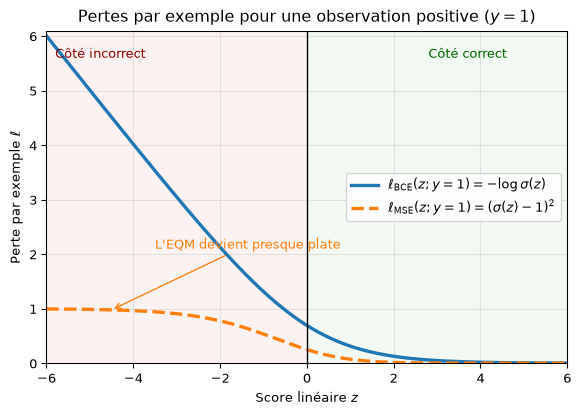

In [2]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(42)

# Fonction sigmoïde
def sigmoid(t):
    return 1 / (1 + np.exp(-t))

# Comparer les pertes en fonction du score linéaire z lorsque y = 1.
z_values = np.linspace(-6, 6, 1000)
p_values = sigmoid(z_values)
bce_values = -np.log(p_values)
mse_values = (p_values - 1) ** 2

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.axvspan(-6, 0, color='tab:red', alpha=0.06)
ax.axvspan(0, 6, color='tab:green', alpha=0.06)
ax.plot(
    z_values,
    bce_values,
    color='tab:blue',
    linewidth=2.5,
    label=r'$\ell_{\mathrm{BCE}}(z;y=1)=-\log \sigma(z)$',
)
ax.plot(
    z_values,
    mse_values,
    color='tab:orange',
    linewidth=2.5,
    linestyle='--',
    label=r'$\ell_{\mathrm{MSE}}(z;y=1)=(\sigma(z)-1)^2$',
)
ax.axvline(0, color='black', linewidth=1)

ax.text(-5.8, 5.6, 'Côté incorrect', color='darkred')
ax.text(2.8, 5.6, 'Côté correct', color='darkgreen')
ax.annotate(
    "L'EQM devient presque plate",
    xy=(-4.5, mse_values[np.argmin(np.abs(z_values + 4.5))]),
    xytext=(-3.5, 2.1),
    arrowprops={'arrowstyle': '->', 'color': 'tab:orange'},
    color='tab:orange',
)

ax.set_xlim(-6, 6)
ax.set_ylim(0, 6.1)
ax.set_xlabel(r'Score linéaire $z$')
ax.set_ylabel(r'Perte par exemple $\ell$')
ax.set_title(r'Pertes par exemple pour une observation positive ($y=1$)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

Pour un exemple où $y=1$ et $\hat{p}=\sigma(z)$ :

$$
\ell_{\mathrm{BCE}}(z;y=1)=-\log\sigma(z),
\qquad
\ell_{\mathrm{MSE}}(z;y=1)=(\sigma(z)-1)^2.
$$

Pour un exemple positif, les scores négatifs correspondent à des
prédictions incorrectes. Lorsque $z$ devient fortement négatif,
l’entropie croisée binaire continue d’augmenter. La perte quadratique
tend plutôt vers 1 et devient presque plate.

La faible pente de la courbe de l’EQM correspond à un gradient faible,
même si la prédiction incorrecte est faite avec une grande confiance.
Pour $y=0$, les courbes sont réfléchies horizontalement.

Chaque courbe montre la perte $\ell$ pour un exemple. L’objectif
d’entraînement $J(\theta)$ est la moyenne de ces pertes sur l’ensemble
d’entraînement :

$$
J(\theta)=\frac{1}{N}\sum_{i=1}^{N}\ell(\theta^\top x_i;y_i).
$$

## Pourquoi ne pas utiliser l’EQM?

- L’**entropie croisée binaire** est la **log-vraisemblance négative**
  du **modèle de Bernoulli**.
- Avec l’**entropie croisée binaire**, l’objectif de la régression
  logistique est **convexe** par rapport aux paramètres.
- Avec une sortie **sigmoïde**, l’**EQM** n’est **pas globalement
  convexe** par rapport au score linéaire. Son **gradient** peut aussi
  devenir **très faible** lorsque le modèle produit avec confiance une
  **prédiction incorrecte**.

Nous reviendrons sur l’entropie croisée lors de l’étude des réseaux de
neurones, notamment en combinaison avec la fonction softmax.

Explications facultatives :

- [Cross Entropy vs. MSE as Cost Function for Logistic Regression for
  Classification](https://www.youtube.com/watch?v=m0ZeT1EWjjI)
- [What is the difference between negative log likelihood and cross
  entropy?](https://www.youtube.com/watch?v=ziq967YrSsc)

En régression linéaire, l’EQM est convexe parce que la prédiction est
linéaire par rapport aux paramètres. Le problème vient ici de la
composition de l’EQM avec la sigmoïde non linéaire.

# Interprétation géométrique

## Interprétation géométrique

- Soit $w=(\theta_1,\ldots,\theta_D)^\top$ le **vecteur des poids des
  attributs**.

- La partie du score linéaire qui dépend des attributs est un **produit
  scalaire** : $$
  w^\top x = \theta_1 x_1 + \theta_2 x_2 + \ldots + \theta_D x_D.
  $$

- Le **score linéaire** complet comprend l’**ordonnée à l’origine** : $$
  t(x)=\theta_0 + w^\top x.
  $$

- Le **produit scalaire** possède une **interprétation géométrique**. $$
  w^\top x = \|w\|\|x\|\cos\phi
  $$

Le vecteur complet des paramètres est
$\theta=(\theta_0,\theta_1,\ldots,\theta_D)^\top$. Le vecteur $w$ ne
contient que les poids des attributs.

## Interprétation géométrique

$$
w^\top x = \|w\|\|x\|\cos\phi
$$

- Le **produit scalaire** dépend à la fois de la **norme des vecteurs**
  et de l’**angle** qui les sépare.
- Il est **positif** lorsque l’angle est **aigu**, et **négatif**
  lorsque l’angle est **obtus**.
- Il est **nul** lorsque les vecteurs sont **perpendiculaires**
  $(\phi=90^\circ)$.

## Interprétation géométrique

- La **régression logistique** applique la sigmoïde au score linéaire
  $t(x)=\theta_0+w^\top x$.

- L’équation $t(x)=0$ définit un hyperplan dans l’espace des attributs.

- Le vecteur des poids $w$ est normal à cet hyperplan. L’ordonnée à
  l’origine $\theta_0$ déplace la frontière sans en modifier
  l’orientation.

## Interprétation géométrique

- La **frontière de décision** correspond à $t(x)=0$.

- Les points pour lesquels $t(x)>0$ reçoivent une probabilité supérieure
  à $0.5$.

- Les points pour lesquels $t(x)<0$ reçoivent une probabilité inférieure
  à $0.5$.

- La sigmoïde transforme le **score linéaire** en probabilité. La
  distance signée à la frontière est $$
  \frac{t(x)}{\|w\|}.
  $$

# Mise en œuvre

## Mise en œuvre : génération des données

In [3]:
# Générer des données synthétiques pour un problème de classification binaire

m = 100  # nombre d'exemples
d = 2    # nombre d'attributs

X = rng.standard_normal((m, d))

# Définir les étiquettes à l'aide d'une frontière linéaire et d'un peu de bruit

noise = 0.5 * rng.standard_normal(m)

y = (X[:, 0] + X[:, 1] + noise > 0).astype(int)

## Mise en œuvre : visualisation

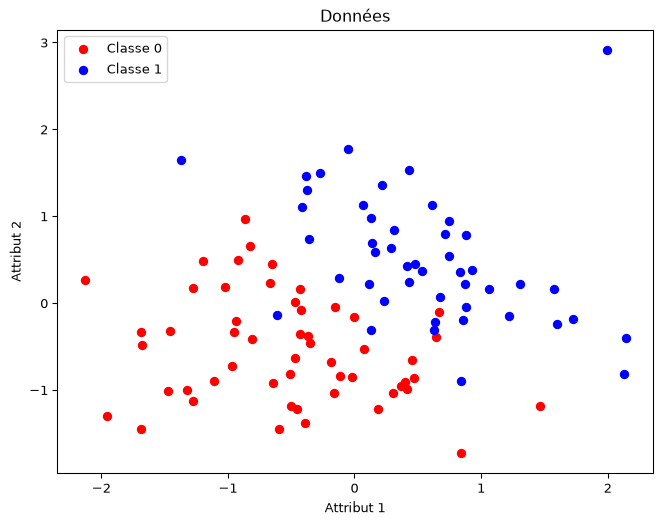

In [4]:
# Visualiser les données
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Classe 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Classe 1')

plt.xlabel("Attribut 1")
plt.ylabel("Attribut 2")
plt.title("Données")
plt.legend()
plt.show()

## Mise en œuvre : fonction de coût

In [5]:
# Fonction de coût : entropie croisée binaire
def cost_function(theta, X, y):
    m = len(y)
    h = sigmoid(X.dot(theta))
    h = np.clip(h, 1e-12, 1 - 1e-12)
    cost = -(1/m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return cost

# Gradient de la fonction de coût
def gradient(theta, X, y):
    m = len(y)
    h = sigmoid(X.dot(theta))
    grad = (1/m) * X.T.dot(h - y)
    return grad

## Mise en œuvre : régression logistique

In [6]:
# Entraînement de la régression logistique par descente de gradient
def logistic_regression(X, y, learning_rate=0.1, iterations=1000):
    m, n = X.shape
    theta = np.zeros(n)
    cost_history = []
    
    for i in range(iterations):
        theta -= learning_rate * gradient(theta, X, y)
        cost_history.append(cost_function(theta, X, y))
        
    return theta, cost_history

## Entraînement

In [7]:
# Ajouter le terme constant (biais)
X_with_intercept = np.hstack([np.ones((m, 1)), X])

# Entraîner le modèle de régression logistique
theta, cost_history = logistic_regression(X_with_intercept, y, learning_rate=0.1, iterations=1000)
theta_0 = theta[0]
w = theta[1:]

print("Theta optimisé :", theta)

Theta optimisé : [-0.28250171  3.11670841  3.46892095]

## Convergence de la fonction de coût

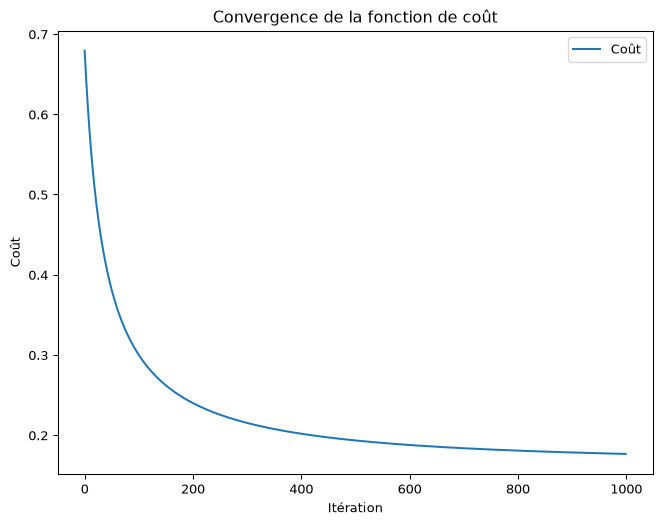

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(cost_history, label="Coût")
plt.xlabel("Itération")
plt.ylabel("Coût")
plt.title("Convergence de la fonction de coût")
plt.legend()
plt.show()

## Frontière de décision et données

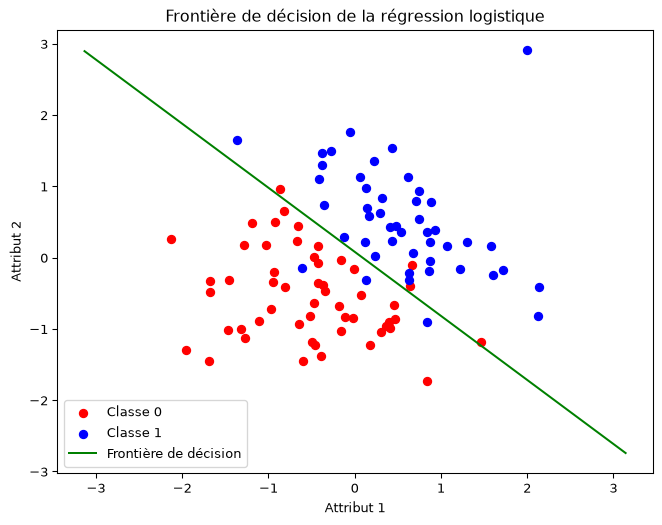

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Classe 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Classe 1')

# Frontière de décision : theta_0 + w[0]*x1 + w[1]*x2 = 0
x_vals = np.array([min(X[:, 0]) - 1, max(X[:, 0]) + 1])
y_vals = -(theta_0 + w[0] * x_vals) / w[1]
plt.plot(x_vals, y_vals, label='Frontière de décision', color='green')
plt.xlabel("Attribut 1")
plt.ylabel("Attribut 2")
plt.title("Frontière de décision de la régression logistique")
plt.legend()
plt.show()

## Visualisation du vecteur des poids

Le vecteur ajusté des poids des attributs $w=(\theta_1,\theta_2)^\top$
est **normal** à la frontière de décision.

L’ordonnée à l’origine $\theta_0$ détermine la position de la frontière.

## Visualisation du vecteur des poids

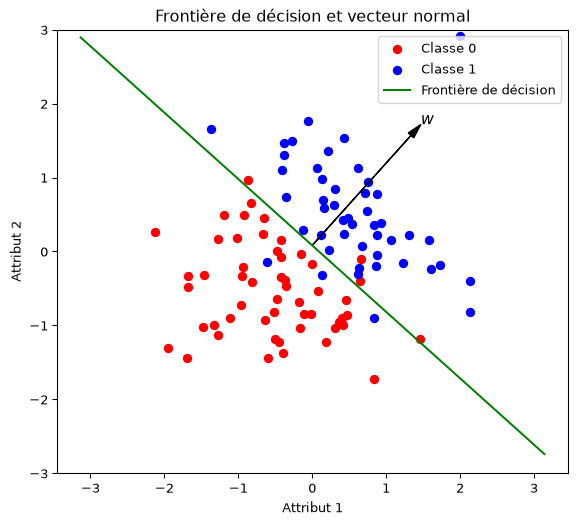

In [10]:
# Tracer la frontière de décision et les données
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Classe 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Classe 1')

# Frontière de décision : theta_0 + w[0]*x1 + w[1]*x2 = 0
x_vals = np.array([min(X[:, 0]) - 1, max(X[:, 0]) + 1])
y_vals = -(theta_0 + w[0] * x_vals) / w[1]
plt.plot(x_vals, y_vals, label='Frontière de décision', color='green')

# --- Tracer le vecteur normal ---
# Le vecteur normal est w.
# Choisir un point de référence sur la frontière. Ici, x1 = 0 :
x_ref = 0
y_ref = -theta_0 / w[1]

# Copier le vecteur des poids pour l'affichage.
normal = w.copy()

# Normaliser et redimensionner pour l'affichage
normal_norm = np.linalg.norm(normal)
if normal_norm != 0:
    normal_unit = normal / normal_norm
else:
    normal_unit = normal
scale = 2  # ajuster l'échelle au besoin
normal_display = normal_unit * scale

# Tracer une flèche à partir du point de référence
plt.arrow(x_ref, y_ref, normal_display[0], normal_display[1],
          head_width=0.1, head_length=0.2, fc='black', ec='black')
plt.text(x_ref + normal_display[0]*1.1, y_ref + normal_display[1]*1.1, 
         r'$w$', color='black', fontsize=12)

plt.xlabel("Attribut 1")
plt.ylabel("Attribut 2")
plt.title("Frontière de décision et vecteur normal")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.ylim(-3, 3)
plt.show()

## Près de la frontière de décision

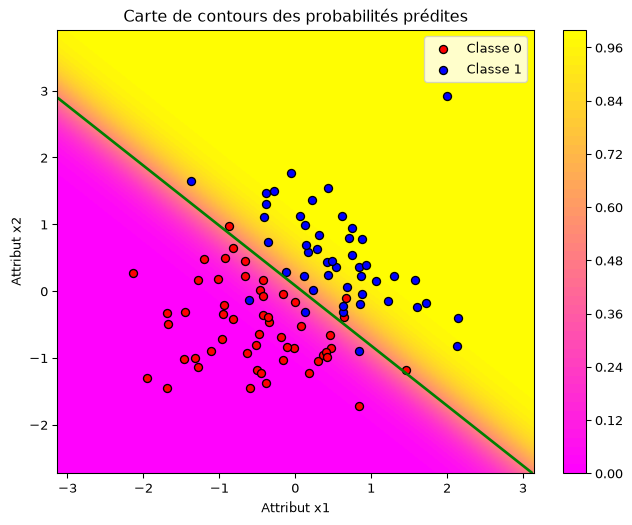

In [11]:
# --- Préparation de la visualisation ---
# Créer une grille dans l'espace des attributs
x1_range = np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 100)
x2_range = np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 100)
xx1, xx2 = np.meshgrid(x1_range, x2_range)

# Construire les entrées de la grille (avec l'ordonnée à l'origine)
grid = np.c_[np.ones(xx1.ravel().shape), xx1.ravel(), xx2.ravel()]
# Calculer les probabilités prédites sur la grille
probs = sigmoid(grid.dot(theta)).reshape(xx1.shape)
# --- Carte de contours en deux dimensions ---
plt.figure(figsize=(8, 6))
contour = plt.contourf(xx1, xx2, probs, cmap='spring', levels=50)
plt.colorbar(contour)
plt.contour(xx1, xx2, probs, levels=[0.5], colors='green', linewidths=2)
plt.xlabel('Attribut x1')
plt.ylabel('Attribut x2')
plt.title('Carte de contours des probabilités prédites')
# Superposer les données d'entraînement
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', edgecolor='k', label='Classe 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', edgecolor='k', label='Classe 1')
plt.legend()
plt.show()

# Épilogue

## Sommaire

- La régression logistique modélise la probabilité d’un **résultat
  binaire**.
- **Maximiser la vraisemblance de Bernoulli** équivaut à **minimiser
  l’entropie croisée binaire**.
- L’entropie croisée **pénalise fortement** les prédictions
  **incorrectes** faites avec confiance.
- L’équation $\theta_0+w^\top x=0$ définit la **frontière de décision**,
  et le vecteur des poids $w$ lui est normal.
- La **descente de gradient par lot** met à jour les paramètres à partir
  du gradient moyen sur l’ensemble d’entraînement.

## Prochain cours

- Mesures de performance et évaluation des modèles

## Références

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de génie électrique et d’**informatique** (**ÉÉ**CS)

Université d’Ottawa